** Almabetter Capstone Project: Deep Learning for NLP**

CONTRIBUTION - INDIVIDUAL

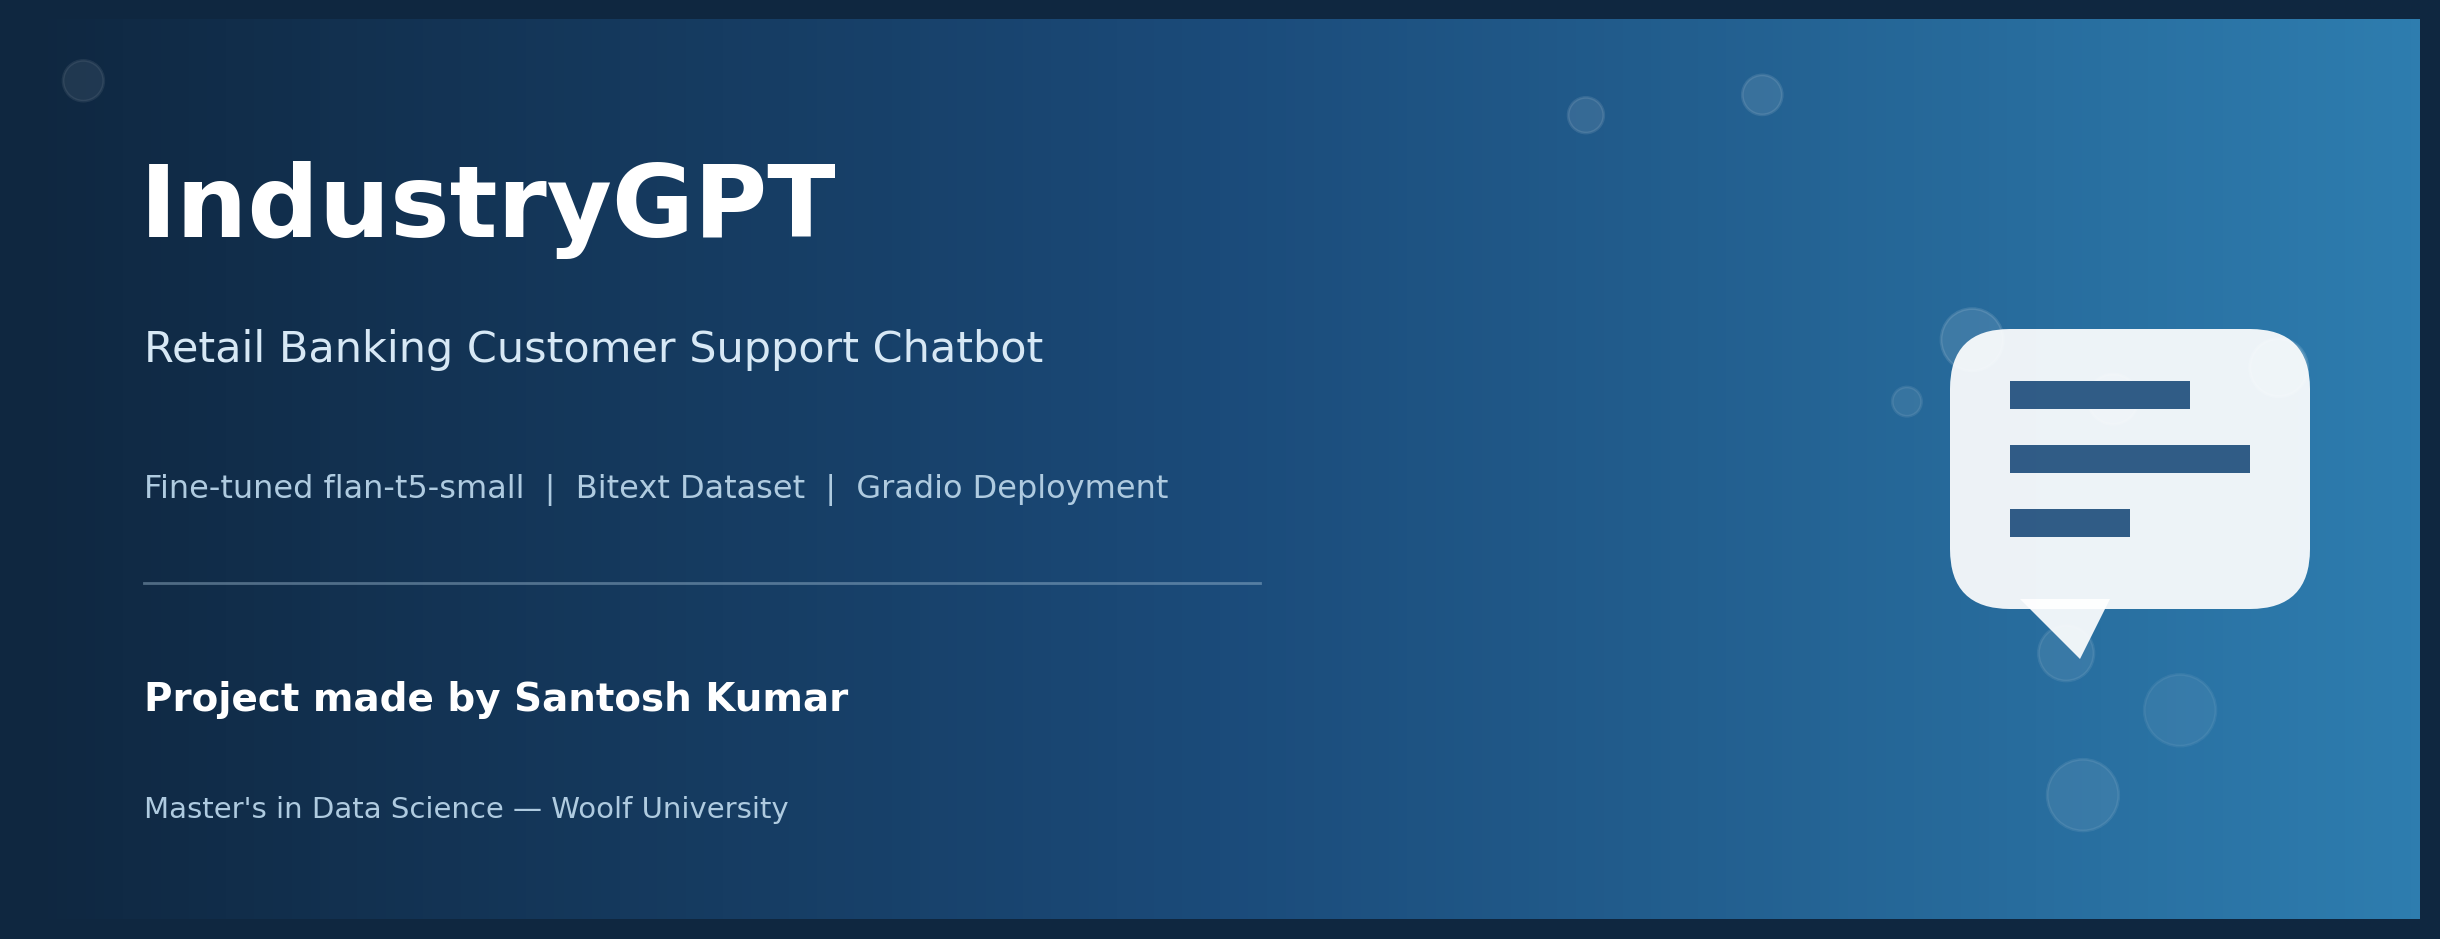

GITHUB - https://github.com/sant8ntl-max/Chat_Bot_LLM

**Project Report (Docx) :** https://docs.google.com/document/d/1Z3C_zdvHq1h1bjjZkWSRbPOJAl4YXpqL/edit?usp=sharing&ouid=107942579187620537544&rtpof=true&sd=true

**Research Paper Docs:**  https://docs.google.com/document/d/1i5GStix3iMwfM_2AVCfFhzSJxoAJ14df/edit?usp=sharing&ouid=107942579187620537544&rtpof=true&sd=true

in this capstone project, students will embark on an exciting journey to create an Industry-Specific Large Language Model (LLM) Bot using state-of-the-art pre-trained models from sources like Hugging Face. The primary objective is to build an intelligent bot that can effectively engage with users by answering questions and providing insights specific to a chosen industry. This project will not only enhance your technical skills but also provide a deep understanding of the chosen industry's nuances, challenges, and trends.

In this project, we developed an industry-specific chatbot for the retail banking sector using a fine-tuned large language model (LLM). The primary goal was to create an AI assistant capable of answering real customer queries about banking services such as account balance checks, card activation, ATM location, loan applications, and more.

We used the publicly available Bitext Retail Banking Chatbot Dataset, which includes thousands of real-world banking prompts and professional, human-like responses. The model was fine-tuned using Google’s FLAN-T5-small on cleaned Q&A pairs, and deployed using a Gradio web interface for user-friendly interaction.

This chatbot demonstrates how LLMs can be effectively adapted to specialized industries like banking, delivering fast, informative, and polite responses — similar to a live customer support agent.



In [ ]:
pip install transformers datasets scikit-learn gradio


In [ ]:
import pandas as pd

# Load the CSV file



df = pd.read_parquet("hf://datasets/bitext/Bitext-retail-banking-llm-chatbot-training-dataset/bitext-retail-banking-llm-chatbot-training-dataset.parquet")

# Keep only needed columns and drop missing values
df_clean = df[['instruction', 'response']].dropna()
df_clean = df_clean[df_clean['instruction'].str.strip() != ""]
df_clean = df_clean[df_clean['response'].str.strip() != ""]
df_clean = df_clean.drop_duplicates(subset=['instruction', 'response'])

# Rename for model input/output
df_clean = df_clean.rename(columns={"instruction": "input", "response": "output"})

# Preview
df_clean.sample(3)


,input,output
17282,I would like to contact fucking client service...,I sincerely apologize for any frustration or i...
6318,wanna cancel a loan where do i do i,I gather that you're looking to cancel your lo...
4284,what to do if i have lost my vosa help me to l...,I'm sorry to hear that you've lost your {{Cred...


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df_clean, test_size=0.1, random_state=42)


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  308MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer(...): Converts text into numerical token IDs that the model can process.

padding="max_length": Ensures all input/output are the same length.

truncation=True: Cuts off anything longer than 128 tokens.

input_enc["labels"] = target_enc["input_ids"]: Assigns the correct response tokens as labels for the model to learn from.



In [ ]:
from datasets import Dataset

# Convert to Hugging Face format
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Tokenization function
def tokenize(example):
    input_enc = tokenizer(example["input"], padding="max_length", truncation=True, max_length=128)
    target_enc = tokenizer(example["output"], padding="max_length", truncation=True, max_length=128)
    input_enc["labels"] = target_enc["input_ids"]
    return input_enc

# Tokenize datasets
train_tokenized = train_dataset.map(tokenize)
test_tokenized = test_dataset.map(tokenize)


Map:   0%|          | 0/22990 [00:00<?, ? examples/s]

Map:   0%|          | 0/2555 [00:00<?, ? examples/s]

This block fine-tunes your chatbot to generate banking-related answers based on user questions — preparing it for use in your chatbot app.

Let me know if you'd like a visual flowchart or want to add an evaluation step after training!

In [ ]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq

training_args = Seq2SeqTrainingArguments(
    output_dir="./banking_bot",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    predict_with_generate=True,
    num_train_epochs=3
)

collator = DataCollatorForSeq2Seq(tokenizer, model=model)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    data_collator=collator
)

trainer.train()

Step,Training Loss
500,2.274008
1000,1.482822
1500,1.328697
2000,1.256722
2500,1.216479
3000,1.158372
3500,1.117616
4000,1.090103
4500,1.056253
5000,1.064659


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=17244, training_loss=1.0460687335144199, metrics={'train_runtime': 2368.3861, 'train_samples_per_second': 29.121, 'train_steps_per_second': 7.281, 'total_flos': 3205217027358720.0, 'train_loss': 1.0460687335144199, 'epoch': 3.0})

In [ ]:
# prompt: give testing accuracy training accuracy and validation accuracy

# After trainer.train()
import json

# Function to extract metrics from logs
def get_metrics(log_history):
    train_loss = None
    eval_loss = None
    # Find the final training loss
    for log in log_history:
        if 'loss' in log:
            train_loss = log['loss']
        if 'eval_loss' in log:
            eval_loss = log['eval_loss']
    return train_loss, eval_loss

train_loss, eval_loss = get_metrics(trainer.state.log_history)

print(f"Training Loss (last logged): {train_loss}")
print(f"Validation Loss (last epoch): {eval_loss}")

# To get evaluation metrics on the test set after training
eval_results = trainer.evaluate(test_tokenized)
print(f"Test Evaluation Results: {eval_results}")

# Note: For accuracy in seq2seq models, it's usually not a single number
# like classification accuracy. Metrics like ROUGE, BLEU are common.
# If you need specific accuracy-like metrics, you would need to implement
# or use a library for sequence generation evaluation metrics and potentially
# override the compute_metrics function in the Trainer or perform manual evaluation.
# The default evaluation in Seq2SeqTrainer provides loss.



Training Loss (last logged): 0.8985822143554687
Validation Loss (last epoch): None


Training Loss,Validation Loss,Step
0.898582,0.763371,17244


Test Evaluation Results: {'eval_loss': 0.7633710503578186}


In [ ]:
model.save_pretrained("banking-chatbot")
tokenizer.save_pretrained("banking-chatbot")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('banking-chatbot/tokenizer_config.json', 'banking-chatbot/tokenizer.json')

In [ ]:
import torch

def chat(prompt):
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Tokenize and move tensors to the same device as model
    inputs = tokenizer(prompt, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Generate response
    with torch.no_grad():
        output = model.generate(**inputs, max_length=100)

    return tokenizer.decode(output[0], skip_special_tokens=True)


In [ ]:
chat("How can I activate my debit card?")


'I\'m here to assist you with activating your debit card. Activating your card is a simple process. Here\'s what you need to do: 1. Visit our website at Company Website URL. 2. Look for the "Activate Card" or "Card Activation" option. 3. Click on it to proceed with the activation process. 4. You will be prompted to provide your card details, such as the card number, expiration'

In [ ]:
import gradio as gr

In [ ]:
interface = gr.Interface(
    fn=chat,          # The function to wrap with a UI
    inputs=gr.Textbox(label="Your banking question"), # Input component: a textbox for the user's prompt
    outputs=gr.Textbox(label="Chatbot response"), # Output component: a textbox for the chatbot's response
    title="Retail Banking Chatbot" # Title for the Gradio interface
)

In [ ]:
# prompt: deploy gradio

interface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4d85364dc8ae700a7a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://4d85364dc8ae700a7a.gradio.live


In [ ]:
#How can I check my account balance?
#Can I apply for a personal loan online?
#Where can I find the nearest ATM?
#I lost my credit card. What should I do?